## **Part 1: Import Library and Loading Dataset**

In [6]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import pywt
from scipy.signal import butter, filtfilt, resample
from scipy.stats import zscore
from sklearn.metrics import classification_report, confusion_matrix

In [7]:
FS = 250     
WINDOW_SIZE = 2500        
LABEL_NORMAL = 0        
LABEL_AFIB = 1            

In [ ]:
TRAIN_CSV_PATH = "/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/traindata.csv"
# TEST_CSV_PATH  = "/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/Lathifa Konvensional/ekg_20260511_110758.csv"

project_path = "/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/"
model_path = os.path.join(project_path, "catnet_afib_model.h5")
logdir = os.path.join(project_path, "logs")

In [ ]:
def apply_bandpass_filter(sig, fs=FS, lowcut=0.5, highcut=40.0, order=3):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, sig)

def process_training_row(row_signal_400hz):
    sig_250hz = resample(row_signal_400hz, WINDOW_SIZE)
    sig_bpf = apply_bandpass_filter(sig_250hz, fs=FS)
    coeffs = pywt.wavedec(sig_bpf, 'db5', level=5)
    coeffs[0] = np.zeros_like(coeffs[0])
    sig_dwt = pywt.waverec(coeffs, 'db5')[:len(sig_bpf)]
    return zscore(sig_dwt)

def process_testing_column(long_signal_250hz):
    sig_bpf = apply_bandpass_filter(long_signal_250hz, fs=FS)
    coeffs = pywt.wavedec(sig_bpf, 'db5', level=5)
    coeffs[0] = np.zeros_like(coeffs[0])
    sig_dwt = pywt.waverec(coeffs, 'db5')[:len(sig_bpf)]
    sig_norm = zscore(sig_dwt)
    
    jendela_terkumpul = []
    for i in range(0, len(sig_norm) - WINDOW_SIZE + 1, WINDOW_SIZE):
        jendela_terkumpul.append(sig_norm[i : i + WINDOW_SIZE])        
    return np.array(jendela_terkumpul)

In [33]:
class ChannelAttention(tf.keras.layers.Layer):
    def __init__(self, filters, ratio=8, **kwargs): 
        super(ChannelAttention, self).__init__(**kwargs)
        self.filters = filters
        self.ratio = ratio

    def build(self, input_shape):
        self.shared_layer_one = tf.keras.layers.Dense(self.filters // self.ratio, activation='relu', kernel_initializer='he_normal')
        self.shared_layer_two = tf.keras.layers.Dense(self.filters, kernel_initializer='he_normal')

    def call(self, inputs):
        avg_pool = tf.keras.layers.GlobalAveragePooling1D()(inputs)
        avg_pool = self.shared_layer_one(avg_pool)
        avg_pool = self.shared_layer_two(avg_pool)
        max_pool = tf.keras.layers.GlobalMaxPooling1D()(inputs)
        max_pool = self.shared_layer_one(max_pool)
        max_pool = self.shared_layer_two(max_pool)
        attention = tf.keras.layers.Add()([avg_pool, max_pool])
        attention = tf.keras.layers.Activation('sigmoid')(attention)
        attention = tf.keras.layers.Reshape((1, self.filters))(attention)
        return tf.keras.layers.Multiply()([inputs, attention])

In [34]:
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.conv1d = tf.keras.layers.Conv1D(filters=1, kernel_size=self.kernel_size, padding='same', activation='sigmoid', kernel_initializer='he_normal', use_bias=False)
    
    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=2, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=2, keepdims=True)
        attention = tf.concat([avg_pool, max_pool], axis=2)
        attention = self.conv1d(attention)
        return inputs * attention

In [ ]:
class TransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_heads, d_model, dff, dropout_rate, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)
        self.multi_head_attention = tf.keras.layers.MultiHeadAttention(key_dim=d_model, num_heads=num_heads)
        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
        self.layer_norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dense1 = tf.keras.layers.Dense(dff, activation='relu')
        self.dense2 = tf.keras.layers.Dense(d_model)
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)
        self.layer_norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

    def call(self, inputs, training=True):
        attn_output = self.multi_head_attention(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layer_norm1(inputs + attn_output)
        ffn_output = self.dense1(out1)
        ffn_output = self.dense2(ffn_output)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layer_norm2(out1 + ffn_output)

In [13]:
def positional_encoding(seq_len, d, n=10000):
    P = np.zeros((seq_len, d))
    for k in range(seq_len):
        for i in np.arange(int(d/2)):
            denominator = np.power(n, 2*i/d)
            P[k, 2*i] = np.sin(k/denominator)
            P[k, 2*i+1] = np.cos(k/denominator)
    return tf.constant(P, dtype=tf.float32)

In [36]:
def buildModel():
    inputs = tf.keras.Input(shape=(WINDOW_SIZE, 1))

    # CNN Block 1
    x = tf.keras.layers.Conv1D(16, 21, padding='same', activation='relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = ChannelAttention(16, 8)(x)
    x = tf.keras.layers.MaxPool1D(3, strides=2, padding='same')(x)

    # CNN Block 2
    x = tf.keras.layers.Conv1D(32, 23, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = ChannelAttention(32, 8)(x)
    x = tf.keras.layers.MaxPool1D(3, strides=2, padding='same')(x)

    # CNN Block 3
    x = tf.keras.layers.Conv1D(64, 25, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = ChannelAttention(64, 8)(x)
    x = tf.keras.layers.AvgPool1D(3, strides=2, padding='same')(x)

    # CNN Block 4
    x = tf.keras.layers.Conv1D(128, 27, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)

    # Menambahkan Positional Encoding sebelum masuk ke Transformer
    pos_enc = positional_encoding(seq_len=x.shape[1], d=x.shape[2])
    x = x + pos_enc

    # Transformer Encoder Block
    x = TransformerEncoder(num_heads=4, d_model=128, dff=256, dropout_rate=0.1)(x)

    # Meratakan dimensi keluaran Transformer
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    
    # Dense Classifier
    x = tf.keras.layers.Dropout(rate=0.4)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(2, activation='softmax')(x)
    
    return tf.keras.Model(inputs, outputs)

In [41]:
train_df = pd.read_csv(TRAIN_CSV_PATH)

X_train_raw = train_df.iloc[0:1000, 0:4000].values 
y_afib = np.ones(500)
y_normal = np.zeros(500)
y_train_urut = np.concatenate([y_afib, y_normal])

print("[INFO] Memproses sinyal 1.000 pasien (BPF -> DWT -> Z-Score)...")
processed_train = [process_training_row(row) for row in X_train_raw]
X_train_urut = np.array(processed_train)
X_train_urut = np.expand_dims(X_train_urut, axis=-1)
acak_indeks = np.arange(X_train_urut.shape[0])
np.random.shuffle(acak_indeks)
x_train = X_train_urut[acak_indeks]
y_train = y_train_urut[acak_indeks]
print(f"-> Data Training Siap (Acak): {x_train.shape}")

[INFO] Memproses sinyal 1.000 pasien (BPF -> DWT -> Z-Score)...
-> Data Training Siap (Acak): (1000, 2500, 1)


In [ ]:
ratio = 0.2

if os.path.exists(model_path):
    print(f"[INFO] Ditemukan model yang sudah dilatih di: {model_path}")
    model = tf.keras.models.load_model(
        model_path,
        custom_objects={
            'ChannelAttention': ChannelAttention,
            'SpatialAttention': SpatialAttention,
            'TransformerEncoder': TransformerEncoder
        }
    )
else:
    print("[INFO] Model belum ada. Memulai proses Training...")
    model = buildModel()
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)
    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath=project_path + "weights.weights.h5",
        save_weights_only=True,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True
    )

    history = model.fit(
        x_train, y_train,
        epochs=50,
        batch_size=128,
        validation_split=ratio,
        callbacks=[tensorboard_callback, checkpoint_cb]
    )
    model.save(model_path)
    print(f"[INFO] Training Selesai! Model disimpan di: {model_path}")

[INFO] Ditemukan model yang sudah dilatih di: /Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/catnet_afib_model.h5


TypeError: too many positional arguments

In [18]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2500, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 2500, 16)       │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2500, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention               │ (None, 2500, 16)       │            82 │
│ (ChannelAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1250, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1250, 32)       │        11,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1250, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention_1             │ (None, 1250, 32)       │           292 │
│ (ChannelAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 625, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 625, 64)        │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 625, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention_2             │ (None, 625, 64)        │         1,096 │
│ (ChannelAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 313, 64)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 313, 128)       │       221,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 313, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_3 (Add)                     │ (None, 313, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 313, 128)       │       330,240 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,51

 Total params: 1,901,570 (7.25 MB)

 Trainable params: 633,696 (2.42 MB)

 Non-trainable params: 480 (1.88 KB)

 Optimizer params: 1,267,394 (4.83 MB)

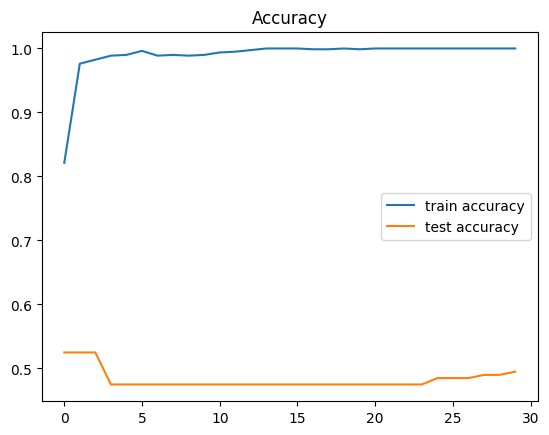

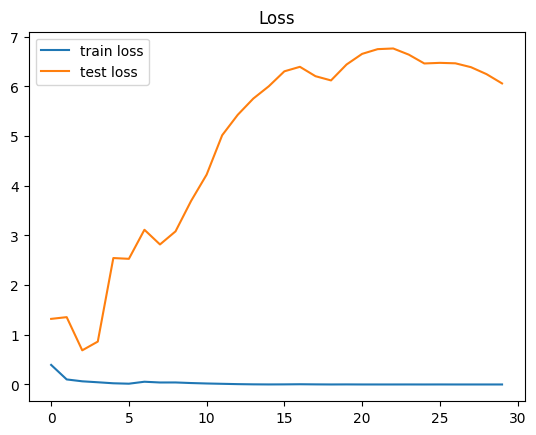

In [43]:
# plot accuracy
plt.title('Accuracy')
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='test accuracy') # label is actually 'validation accuracy'
plt.legend()
plt.show()

# plot loss
plt.title('Loss')
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='test loss') # label is actually 'validation accuracy'
plt.legend()
plt.show()

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)

test_loss, test_acc = model.evaluate(X_test, y_test_asli, verbose=0)
print('Training Accuracy : %.2f%%' % (train_acc * 100))
print('Training Loss     : %.2f%%' % (train_loss * 100))
print('Testing Accuracy  : %.2f%%' % (test_acc * 100))
print('Testing Loss      : %.2f%%' % (test_loss * 100))

Training Accuracy : 51.90%
Training Loss     : 574.92%
Testing Accuracy  : 3.64%
Testing Loss      : 1224.33%


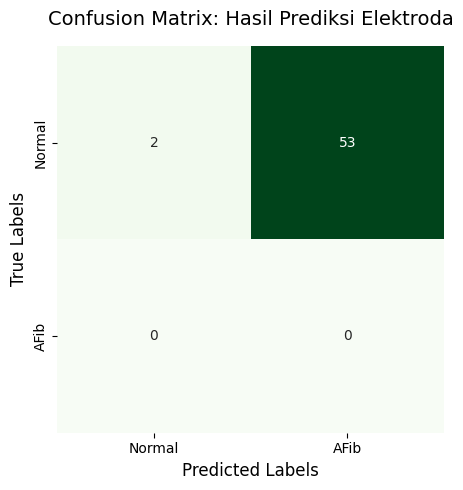

In [29]:
def plotHeatMap(y_true, y_pred):
    con_mat = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))

    sns.heatmap(con_mat, 
                annot=True, 
                square=True, 
                fmt='g',
                cmap='Greens', 
                xticklabels=['Normal', 'AFib'],
                yticklabels=['Normal', 'AFib'],
                cbar=False)
    
    plt.title('Confusion Matrix: Hasil Prediksi Elektroda', pad=15, fontsize=14)
    plt.xlabel('Predicted Labels', fontsize=12)
    plt.ylabel('True Labels', fontsize=12)
    plt.tight_layout()
    plt.show()
plotHeatMap(y_test_asli, prediksi_kelas)

In [30]:
test_df = pd.read_csv(TEST_CSV_PATH)
test_signal_1d = test_df.iloc[:, 2].dropna().values 
X_test = process_testing_column(test_signal_1d)
X_test = np.expand_dims(X_test, axis=-1)

prediksi_prob = model.predict(X_test)
prediksi_kelas = np.argmax(prediksi_prob, axis=1)
y_test_asli = np.zeros(len(prediksi_kelas)) 

print("\nClassification Report:")
try:
    print(classification_report(y_test_asli, prediksi_kelas, target_names=['Normal', 'AFib']))
except ValueError:
    from sklearn.metrics import accuracy_score
    print(f"Akurasi Total: {accuracy_score(y_test_asli, prediksi_kelas) * 100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 341ms/step

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.04      0.07        55
        AFib       0.00      0.00      0.00         0

    accuracy                           0.04        55
   macro avg       0.50      0.02      0.04        55
weighted avg       1.00      0.04      0.07        55



/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
